**Sub questions:**
- (a) Apply gamma correction to the **L plane only** in L\*a\*b\* colour space and state the γ value
- (b) Show histograms of the original and corrected images

**Image:** `highlights_and_shadows.jpg`

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

# Load image — OpenCV reads as BGR
img_bgr = cv.imread('../images/a1images/highlights_and_shadows.jpg')
assert img_bgr is not None, "Could not load highlights_and_shadows.jpg"

# Convert BGR → RGB for correct matplotlib display
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

print(f"Image shape : {img_bgr.shape}")
print(f"Dtype       : {img_bgr.dtype}")
print(f"Min / Max   : {img_bgr.min()} / {img_bgr.max()}")


Image shape : (480, 720, 3)
Dtype       : uint8
Min / Max   : 0 / 255


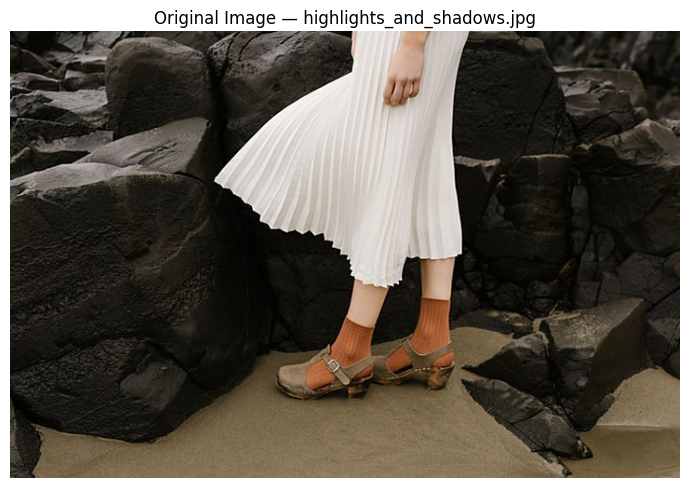

In [3]:
# Display original image
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.imshow(img_rgb)
ax.set_title('Original Image — highlights_and_shadows.jpg', fontsize=12)
ax.axis('off')
plt.tight_layout()
os.makedirs('../outputs/q2', exist_ok=True)
plt.savefig('../outputs/q2/q2_original.png', dpi=150, bbox_inches='tight')
plt.show()


## (a) Gamma Correction on the L Channel

In [4]:
# ── Step 1: Convert BGR → L*a*b* ─────────────────────────────────────────────
img_lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2Lab)

# ── Step 2: Split into L, a*, b* channels ─────────────────────────────────────
L, a, b = cv.split(img_lab)

print(f"L channel — Min: {L.min()}, Max: {L.max()}, Mean: {L.mean():.2f}, Std: {L.std():.2f}")
print(f"Image is {'DARK (mean < 127) → use γ < 1 to brighten' if L.mean() < 127 else 'BRIGHT (mean > 127) → use γ > 1 to darken'}")


L channel — Min: 0, Max: 255, Mean: 71.26, Std: 69.73
Image is DARK (mean < 127) → use γ < 1 to brighten


In [5]:
# ── Step 3: Apply gamma correction to L channel only ─────────────────────────

GAMMA = 0.45   # γ < 1 brightens the image; stated value for the report

def gamma_correct_channel(channel_uint8, gamma):
    """
    Apply gamma correction to a single uint8 channel.
    Steps:
      1. Normalize to [0, 1]
      2. Apply power law: s = r^gamma
      3. Scale back to [0, 255] as uint8
    """
    # Normalize to float [0, 1]
    channel_norm = channel_uint8.astype(np.float32) / 255.0
    # Apply gamma
    corrected = np.power(channel_norm, gamma)
    # Scale back to uint8
    return (corrected * 255).astype(np.uint8)


L_corrected = gamma_correct_channel(L, GAMMA)

print(f"Gamma applied  : γ = {GAMMA}")
print(f"L original     — Mean: {L.mean():.2f} | Std: {L.std():.2f}")
print(f"L corrected    — Mean: {L_corrected.mean():.2f} | Std: {L_corrected.std():.2f}")


Gamma applied  : γ = 0.45
L original     — Mean: 71.26 | Std: 69.73
L corrected    — Mean: 125.04 | Std: 63.45


In [6]:
# ── Step 4: Merge corrected L with original a* and b* ────────────────────────
img_lab_corrected = cv.merge([L_corrected, a, b])

# ── Step 5: Convert L*a*b* → BGR → RGB for display ───────────────────────────
img_bgr_corrected = cv.cvtColor(img_lab_corrected, cv.COLOR_Lab2BGR)
img_rgb_corrected = cv.cvtColor(img_bgr_corrected, cv.COLOR_BGR2RGB)

print("Corrected image shape :", img_bgr_corrected.shape)
print("Corrected image dtype :", img_bgr_corrected.dtype)


Corrected image shape : (480, 720, 3)
Corrected image dtype : uint8


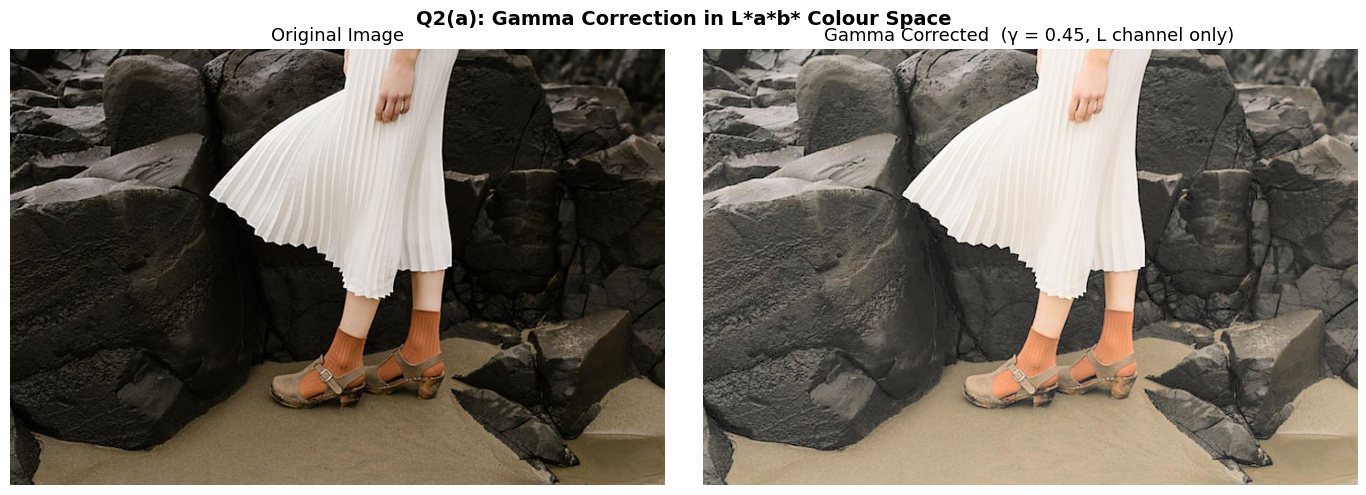

In [7]:
# ── Visual comparison: original vs corrected ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_rgb)
axes[0].set_title('Original Image', fontsize=13)
axes[0].axis('off')

axes[1].imshow(img_rgb_corrected)
axes[1].set_title(f'Gamma Corrected  (γ = {GAMMA}, L channel only)', fontsize=13)
axes[1].axis('off')

plt.suptitle('Q2(a): Gamma Correction in L*a*b* Colour Space', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/q2/q2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## (b) Histograms of Original and Corrected Images

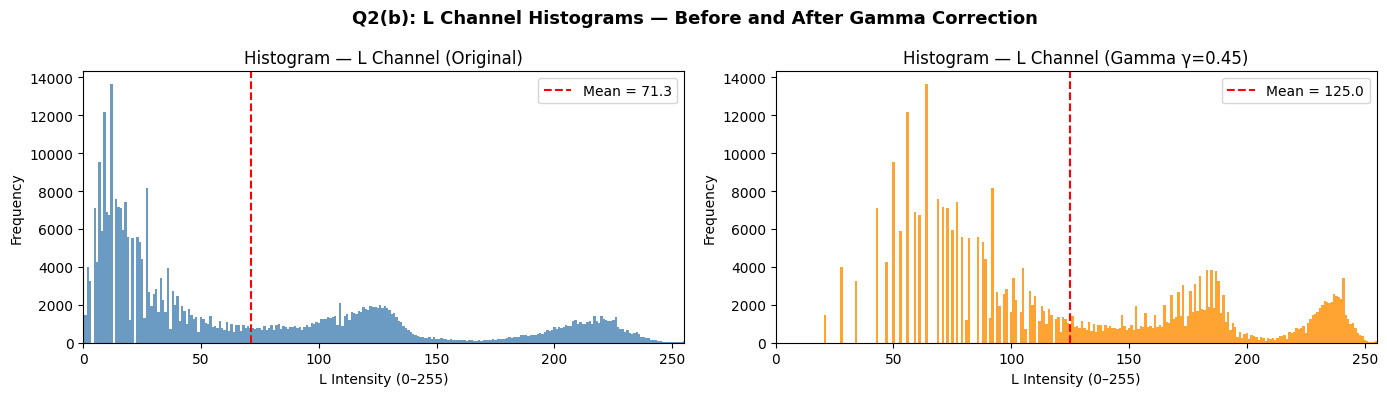

In [8]:
# ── Compute histograms of L channel before and after ─────────────────────────
hist_L_orig = np.histogram(L.ravel(),           bins=256, range=(0, 256))[0]
hist_L_corr = np.histogram(L_corrected.ravel(), bins=256, range=(0, 256))[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(256), hist_L_orig, color='steelblue', alpha=0.8, width=1.0)
axes[0].set_title('Histogram — L Channel (Original)', fontsize=12)
axes[0].set_xlabel('L Intensity (0–255)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim([0, 255])
axes[0].axvline(L.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean = {L.mean():.1f}')
axes[0].legend()

axes[1].bar(range(256), hist_L_corr, color='darkorange', alpha=0.8, width=1.0)
axes[1].set_title(f'Histogram — L Channel (Gamma γ={GAMMA})', fontsize=12)
axes[1].set_xlabel('L Intensity (0–255)')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim([0, 255])
axes[1].axvline(L_corrected.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean = {L_corrected.mean():.1f}')
axes[1].legend()

plt.suptitle('Q2(b): L Channel Histograms — Before and After Gamma Correction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/q2/q2_histograms_L.png', dpi=150, bbox_inches='tight')
plt.show()


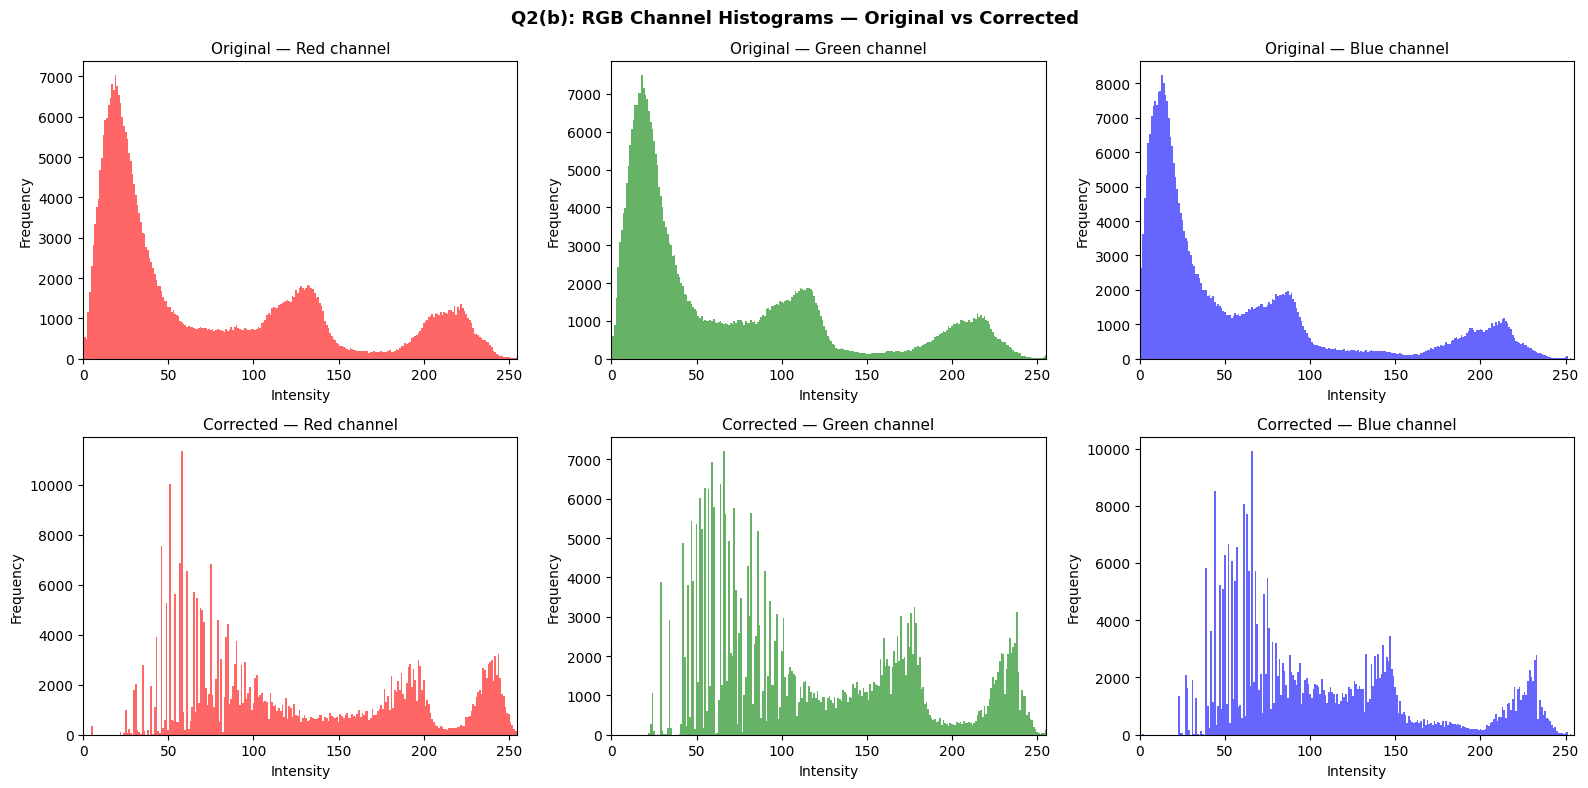

In [9]:
# ── Also show full RGB histograms of original vs corrected ──────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Q2(b): RGB Channel Histograms — Original vs Corrected', fontsize=13, fontweight='bold')

channel_names  = ['Red', 'Green', 'Blue']
channel_colors = ['red', 'green', 'blue']

for col, (ch_name, ch_color) in enumerate(zip(channel_names, channel_colors)):
    # Original
    hist_orig = np.histogram(img_rgb[:,:,col].ravel(), bins=256, range=(0,256))[0]
    axes[0, col].bar(range(256), hist_orig, color=ch_color, alpha=0.6, width=1.0)
    axes[0, col].set_title(f'Original — {ch_name} channel', fontsize=11)
    axes[0, col].set_xlim([0, 255])
    axes[0, col].set_xlabel('Intensity')
    axes[0, col].set_ylabel('Frequency')

    # Corrected
    hist_corr = np.histogram(img_rgb_corrected[:,:,col].ravel(), bins=256, range=(0,256))[0]
    axes[1, col].bar(range(256), hist_corr, color=ch_color, alpha=0.6, width=1.0)
    axes[1, col].set_title(f'Corrected — {ch_name} channel', fontsize=11)
    axes[1, col].set_xlim([0, 255])
    axes[1, col].set_xlabel('Intensity')
    axes[1, col].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../outputs/q2/q2_histograms_RGB.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# ── Statistics summary ───────────────────────────────────────────────────────
print(f"Gamma value used: γ = {GAMMA}  (γ < 1 → brightening)")
print()
print(f"{'Channel':<20} {'Mean (orig)':>12} {'Mean (corr)':>12} {'Std (orig)':>11} {'Std (corr)':>11}")
print("-" * 70)

# L channel
print(f"{'L (luminance)':<20} {L.mean():>12.2f} {L_corrected.mean():>12.2f} "
      f"{L.std():>11.2f} {L_corrected.std():>11.2f}")

# RGB channels
ch_names = ['Red', 'Green', 'Blue']
for i, name in enumerate(ch_names):
    orig_ch = img_rgb[:,:,i]
    corr_ch = img_rgb_corrected[:,:,i]
    print(f"{name:<20} {orig_ch.mean():>12.2f} {corr_ch.mean():>12.2f} "
          f"{orig_ch.std():>11.2f} {corr_ch.std():>11.2f}")


Gamma value used: γ = 0.45  (γ < 1 → brightening)

Channel               Mean (orig)  Mean (corr)  Std (orig)  Std (corr)
----------------------------------------------------------------------
L (luminance)               71.26       125.04       69.73       63.45
Red                         75.71       126.28       69.67       68.11
Green                       68.57       118.28       65.45       62.32
Blue                        58.07       107.32       63.56       58.43
